# Skin Lesion Bias Reduction — cGAN training (Colab)

Trains the conditional DCGAN-style GAN at `src/train.py` on Fitzpatrick17k using a Colab GPU.

**Order of operations**
1. Confirm GPU + mount Drive
2. Point the notebook at your code + data
3. Cache images locally for fast IO
4. Pull the latest repo from `origin/main`
5. Install dependencies
6. *(optional)* Run segmentation-aware preprocessing (cv2 / SAM2 / MedSAM3)
7. Configure cGAN hyperparameters
8. Train the cGAN
9. *(optional)* Resume from a checkpoint
10. Watch progress in TensorBoard
11. Generate synthetic samples for underrepresented (FST 5/6) cells

## 1. Verify GPU and Colab environment

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules
print("Colab:", IN_COLAB)

import torch
print("torch:", torch.__version__, "cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    !nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv

Colab: True
torch: 2.10.0+cu128 cuda available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
name, memory.total [MiB], memory.free [MiB]
NVIDIA RTX PRO 6000 Blackwell Server Edition, 97887 MiB, 97248 MiB


## 2. Connect your code and data

Edit `PROJECT_ROOT`, `DATASET_CSV`, and `IMAGE_DIR` to match where the repo and dataset live on your Drive. The paths below assume the same layout as `colab_training.ipynb`.

In [2]:
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path

# === EDIT THESE ===
PROJECT_ROOT = Path("/content/drive/MyDrive/SkinLesionBiasReduction")
IMAGE_DIR    = PROJECT_ROOT / "dataset/images"
DATASET_CSV  = PROJECT_ROOT / "dataset/fitzpatrick17k_cleaned.csv"
# ==================

print("PROJECT_ROOT:", PROJECT_ROOT, "exists:", PROJECT_ROOT.exists())
print("IMAGE_DIR:   ", IMAGE_DIR,    "exists:", IMAGE_DIR.exists())
print("DATASET_CSV: ", DATASET_CSV,  "exists:", DATASET_CSV.exists())
assert PROJECT_ROOT.exists(), f"PROJECT_ROOT does not exist: {PROJECT_ROOT}"
assert IMAGE_DIR.exists(),    f"IMAGE_DIR does not exist:    {IMAGE_DIR}"
assert DATASET_CSV.exists(),  f"DATASET_CSV does not exist:  {DATASET_CSV}"

%cd $PROJECT_ROOT

PROJECT_ROOT: /content/drive/MyDrive/SkinLesionBiasReduction exists: True
IMAGE_DIR:    /content/drive/MyDrive/SkinLesionBiasReduction/dataset/images exists: True
DATASET_CSV:  /content/drive/MyDrive/SkinLesionBiasReduction/dataset/fitzpatrick17k_cleaned.csv exists: True
/content/drive/MyDrive/SkinLesionBiasReduction


### 2.1 Cache the images on local disk

Reading 16k JPEGs through Drive's FUSE mount is the throughput bottleneck on Colab. Copy them once to `/content/local_images` (parallel `cp -n`, resumable) and point the trainer at the local copy. The dataset CSV stays on Drive — it's a single small file.

In [4]:
import subprocess, time

DRIVE_IMAGE_DIR = IMAGE_DIR
LOCAL_IMAGE_DIR = Path("/content/local_images")
LOCAL_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

def _count_files(d):
    r = subprocess.run(f"ls -1 '{d}' 2>/dev/null | wc -l",
                       shell=True, capture_output=True, text=True)
    return int(r.stdout.strip() or 0)

n_source = _count_files(DRIVE_IMAGE_DIR)
n_local  = _count_files(LOCAL_IMAGE_DIR)
print(f"Drive: {n_source} files | Local: {n_local} files "
      f"(need ~{max(0, n_source - n_local)} more)")

if n_local >= n_source > 0:
    print("Local cache is complete — skipping copy.")
else:
    print("Parallel-copying from Drive (64 workers)...")
    t0 = time.time()
    cmd = (
        f"cd '{DRIVE_IMAGE_DIR}' && "
        f"find . -maxdepth 1 -type f -print0 | "
        f"xargs -0 -n 64 -P 64 cp -n -t '{LOCAL_IMAGE_DIR}/'"
    )
    subprocess.run(cmd, shell=True, check=True)
    n_local = _count_files(LOCAL_IMAGE_DIR)
    print(f"Done in {time.time()-t0:.1f}s — local now has {n_local} files.")

# Use the local cache for training
TRAIN_IMAGE_DIR = LOCAL_IMAGE_DIR

Drive: 16518 files | Local: 0 files (need ~16518 more)
Parallel-copying from Drive (64 workers)...
Done in 145.6s — local now has 16518 files.


### 2.2 Pull the latest repo state

Discards local edits in the Drive checkout and resets to `origin/main`. Skip this cell if you have uncommitted work on Drive you don't want overwritten.

In [5]:
!git fetch origin main && git reset --hard origin/main

remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 10 (delta 8), reused 10 (delta 8), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 239.30 KiB | 61.00 KiB/s, done.
From https://github.com/hoangnam310/SkinLesionBiasReduction
 * branch            main       -> FETCH_HEAD
   c8e088f..85ef2c1  main       -> origin/main
Updating files: 100% (60/60), done.
HEAD is now at 85ef2c1 Add self attention


## 3. Install dependencies

Colab images already include `torch`, `torchvision`, `numpy`, `pandas`, `Pillow`, `tqdm`, `matplotlib`, `scipy`, and `tensorboard`. The cGAN trainer uses only those — no extra installs needed. The cell below is a no-op safety net in case Colab ever ships a slimmer image.

In [6]:
!pip install --quiet 'tensorboard' 'scipy'

## 4. (Optional) Train on a pre-segmented dataset

If you already built segmented copies of Fitzpatrick17k (the cv2 / SAM2 / SAM3 / MedSAM3 outputs from `colab_training.ipynb` section 6, sitting on Drive at `dataset/images_<backend>_224/`), set `SEG_VARIANT` below to swap them in. The cell mirrors the chosen Drive dir to local disk for IO speed and rebinds `TRAIN_IMAGE_DIR` so the training cell picks it up automatically. Leave `SEG_VARIANT = "none"` to train on the raw images.

In [ ]:
SEG_VARIANT = "cv2"  # "none" | "cv2" | "sam2" | "sam3" | "medsam3"

# Drive paths produced by colab_training.ipynb section 6.
DRIVE_CV2_DIR     = PROJECT_ROOT / "dataset/images_cv2_224"
DRIVE_SAM2_DIR    = PROJECT_ROOT / "dataset/images_sam2_224"
DRIVE_SAM3_DIR    = PROJECT_ROOT / "dataset/images_sam3_224"
DRIVE_MEDSAM3_DIR = PROJECT_ROOT / "dataset/images_medsam3_224"

# Local mirrors (fast IO during training).
LOCAL_CV2_DIR     = Path("/content/local_images_cv2_224")
LOCAL_SAM2_DIR    = Path("/content/local_images_sam2_224")
LOCAL_SAM3_DIR    = Path("/content/local_images_sam3_224")
LOCAL_MEDSAM3_DIR = Path("/content/local_images_medsam3_224")

SEG_DIRS = {
    "cv2":     (DRIVE_CV2_DIR,     LOCAL_CV2_DIR),
    "sam2":    (DRIVE_SAM2_DIR,    LOCAL_SAM2_DIR),
    "sam3":    (DRIVE_SAM3_DIR,    LOCAL_SAM3_DIR),
    "medsam3": (DRIVE_MEDSAM3_DIR, LOCAL_MEDSAM3_DIR),
}
assert SEG_VARIANT == "none" or SEG_VARIANT in SEG_DIRS, \
    f"SEG_VARIANT must be 'none' or one of {sorted(SEG_DIRS)}, got {SEG_VARIANT!r}"

print(f"SEG_VARIANT = {SEG_VARIANT!r}")
if SEG_VARIANT != "none":
    drive_dir, local_dir = SEG_DIRS[SEG_VARIANT]
    print(f"  Drive: {drive_dir} (exists={drive_dir.exists()})")
    print(f"  Local: {local_dir}")

SEG_VARIANT = 'medsam3'
  Drive: /content/drive/MyDrive/SkinLesionBiasReduction/dataset/images_medsam3_224 (exists=True)
  Local: /content/local_images_medsam3_224


In [37]:
# Mirror Drive → local for the chosen variant, then rebind TRAIN_IMAGE_DIR so
# section 6's training cell uses the segmented images. Same parallel-cp pattern
# as section 2.1.
import time

if SEG_VARIANT == "none":
    print("SEG_VARIANT='none' — keeping raw images at:", TRAIN_IMAGE_DIR)
else:
    drive_dir, local_dir = SEG_DIRS[SEG_VARIANT]
    assert drive_dir.exists(), f"Drive dir missing: {drive_dir}"
    local_dir.mkdir(parents=True, exist_ok=True)

    n_src = _count_files(drive_dir)
    n_dst = _count_files(local_dir)
    print(f"[{SEG_VARIANT}] Drive: {n_src} files | Local: {n_dst} files "
          f"(need ~{max(0, n_src - n_dst)} more)")

    if n_dst >= n_src > 0:
        print(f"[{SEG_VARIANT}] Local cache complete — skipping copy.")
    else:
        t0 = time.time()
        cmd = (
            f"cd '{drive_dir}' && "
            f"find . -maxdepth 1 -type f -print0 | "
            f"xargs -0 -n 64 -P 64 cp -n -t '{local_dir}/'"
        )
        subprocess.run(cmd, shell=True, check=True)
        n_dst = _count_files(local_dir)
        print(f"[{SEG_VARIANT}] Done — {n_dst} files in {time.time()-t0:.1f}s")

    TRAIN_IMAGE_DIR = local_dir
    print("TRAIN_IMAGE_DIR is now:", TRAIN_IMAGE_DIR)

[medsam3] Drive: 11059 files | Local: 0 files (need ~11059 more)
[medsam3] Done — 11058 files in 94.9s
TRAIN_IMAGE_DIR is now: /content/local_images_medsam3_224


## 5. Configure cGAN hyperparameters

Defaults match `src/train.py`. Adjust `EPOCHS` and `BATCH_SIZE` to your GPU:
- T4 (~15 GB): `BATCH_SIZE = 64` is comfortable
- A100 (~40 GB): `BATCH_SIZE = 128`+ if you want faster epochs

Outputs land under `PROJECT_ROOT/outputs/<timestamp>/{checkpoints,samples,logs}`. Keeping outputs on Drive means checkpoints survive a runtime disconnect.

In [38]:
EPOCHS              = 200
BATCH_SIZE          = 64
LR                  = 2e-4
BETA1               = 0.5
BETA2               = 0.999
LATENT_DIM          = 100
EMBEDDING_DIM       = 50
NGF                 = 64
NDF                 = 64
LABEL_SMOOTHING     = 0.1
NOISE_STD           = 0.1
NOISE_DECAY         = 0.995
CHECKPOINT_INTERVAL = 10
SAMPLE_INTERVAL     = 5
FID_INTERVAL        = 20
FID_NUM_SAMPLES     = 1000
NUM_WORKERS         = 4

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Outputs will land under:", OUTPUT_DIR)

Outputs will land under: /content/drive/MyDrive/SkinLesionBiasReduction/outputs


## 6. Train the cGAN

Logs go to stdout *and* TensorBoard. A new `outputs/<YYYYMMDD_HHMMSS>/` directory is created at start; record its name from the first few lines of output if you want to resume later.

> **Smoke test:** set `EPOCHS = 1` (and optionally `FID_INTERVAL = 0`) to verify the pipeline before committing to a 200-epoch run.

In [39]:
# !python src/train.py \
#     --csv_path "{DATASET_CSV}" \
#     --image_dir "{TRAIN_IMAGE_DIR}" \
#     --epochs {EPOCHS} \
#     --batch_size {BATCH_SIZE} \
#     --lr {LR} \
#     --beta1 {BETA1} \
#     --beta2 {BETA2} \
#     --latent_dim {LATENT_DIM} \
#     --embedding_dim {EMBEDDING_DIM} \
#     --ngf {NGF} \
#     --ndf {NDF} \
#     --label_smoothing {LABEL_SMOOTHING} \
#     --noise_std {NOISE_STD} \
#     --noise_decay {NOISE_DECAY} \
#     --checkpoint_interval {CHECKPOINT_INTERVAL} \
#     --sample_interval {SAMPLE_INTERVAL} \
#     --fid_interval {FID_INTERVAL} \
#     --fid_num_samples {FID_NUM_SAMPLES} \
#     --num_workers {NUM_WORKERS} \
#     --output_dir "{OUTPUT_DIR}" \
#     --device cuda

## 6.5 Train the WGAN-GP variant (`src/train_wgan.py`)

Tests the new training pipeline: Wasserstein loss with gradient penalty (λ=10), `n_critic=5` critic updates per generator update, DiffAugment (color + translation + cutout) on real / fake / interpolated, and the `Upsample+Conv2d` generator that replaces stride-2 ConvTranspose2d to remove checkerboard artifacts. Adam(β₁=0, β₂=0.9) is the WGAN-GP-standard optimizer setting.

Outputs land under `OUTPUT_DIR/wgan_<YYYYMMDD_HHMMSS>/{checkpoints,samples,logs}` — the `wgan_` prefix keeps these runs separate from the original DCGAN runs above so TensorBoard and checkpoint discovery (sections 8–10) still work without modification.

> **Smoke test first:** set `WGAN_EPOCHS = 1` and `WGAN_FID_INTERVAL = 0` to confirm the pipeline executes (gradient penalty, DiffAugment, n_critic loop, checkpointing) before committing to a long run.

In [40]:
# Smoke test defaults: WGAN_EPOCHS = 1 and WGAN_FID_INTERVAL = 0 to verify the
# pipeline first; bump epochs and re-enable FID for a real run.
WGAN_EPOCHS              = 200
WGAN_BATCH_SIZE          = 64
WGAN_LR_G                = 1e-4
WGAN_LR_C                = 1e-4
WGAN_BETA1               = 0.0
WGAN_BETA2               = 0.9
WGAN_N_CRITIC            = 5
WGAN_LAMBDA_GP           = 10.0
WGAN_DIFFAUG_POLICY      = "color,translation,cutout"
WGAN_GEN_ARCH            = "upsample"   # "upsample" (Upsample+Conv) | "deconv" (ConvTranspose2d)
WGAN_LATENT_DIM          = 100
WGAN_EMBEDDING_DIM       = 50
WGAN_NGF                 = 64
WGAN_NDF                 = 64
WGAN_CHECKPOINT_INTERVAL = 10
WGAN_SAMPLE_INTERVAL     = 5
WGAN_FID_INTERVAL        = 20
WGAN_FID_NUM_SAMPLES     = 1000
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Outputs will land under:", OUTPUT_DIR)
print("WGAN-GP outputs land under:", OUTPUT_DIR, "/ wgan_<timestamp>")

Outputs will land under: /content/drive/MyDrive/SkinLesionBiasReduction/outputs
WGAN-GP outputs land under: /content/drive/MyDrive/SkinLesionBiasReduction/outputs / wgan_<timestamp>


In [41]:
# !python src/train_wgan.py \
#     --csv_path "{DATASET_CSV}" \
#     --image_dir "{TRAIN_IMAGE_DIR}" \
#     --epochs {WGAN_EPOCHS} \
#     --batch_size {WGAN_BATCH_SIZE} \
#     --lr_g {WGAN_LR_G} \
#     --lr_c {WGAN_LR_C} \
#     --beta1 {WGAN_BETA1} \
#     --beta2 {WGAN_BETA2} \
#     --n_critic {WGAN_N_CRITIC} \
#     --lambda_gp {WGAN_LAMBDA_GP} \
#     --diffaug_policy "{WGAN_DIFFAUG_POLICY}" \
#     --gen_arch {WGAN_GEN_ARCH} \
#     --latent_dim {WGAN_LATENT_DIM} \
#     --embedding_dim {WGAN_EMBEDDING_DIM} \
#     --ngf {WGAN_NGF} \
#     --ndf {WGAN_NDF} \
#     --checkpoint_interval {WGAN_CHECKPOINT_INTERVAL} \
#     --sample_interval {WGAN_SAMPLE_INTERVAL} \
#     --fid_interval {WGAN_FID_INTERVAL} \
#     --fid_num_samples {WGAN_FID_NUM_SAMPLES} \
#     --num_workers {NUM_WORKERS} \
#     --output_dir "{OUTPUT_DIR}" \
#     --device cuda

## 6.6 WGAN-GP + Self-Attention + LayerNorm

Adds two architectural improvements on top of section 6.5 to push past the FID-141 plateau and fix the "blob" problem:

- **SelfAttention** (SAGAN-style, 1×1 query/key/value with `gamma=0` init) at the 32×32 stage in **both** Generator and Critic. Lets the model reason about long-range spatial dependencies — e.g. "this lesion edge has to be consistent with the skin texture across the image". Starts as the identity and gradually learns when to use attention.
- **LayerNorm** in the Critic (the original Gulrajani 2017 WGAN-GP paper recommendation) instead of InstanceNorm.

**Memory note:** each attention map is shape `(B, 1024, 1024)` ≈ 256 MB at batch=64 fp32. Comfortable on A100; if you OOM on T4, set `WGAN2_BATCH_SIZE = 32`.

Outputs land under `OUTPUT_DIR/wgan_<YYYYMMDD_HHMMSS>/`. TensorBoard, sample preview (section 9), and generation (section 10) all auto-discover the new run — `generate.py` auto-detects attention from the checkpoint's state_dict keys.

In [42]:
# Section 6.5 hyperparameters + the new architecture flags.
WGAN2_EPOCHS              = 200
WGAN2_BATCH_SIZE          = 64        
WGAN2_LR_G                = 1e-4
WGAN2_LR_C                = 1e-4
WGAN2_BETA1               = 0.0
WGAN2_BETA2               = 0.9
WGAN2_N_CRITIC            = 5
WGAN2_LAMBDA_GP           = 10.0
WGAN2_DIFFAUG_POLICY      = "color,translation,cutout"
WGAN2_GEN_ARCH            = "upsample"

# New architecture flags:
WGAN2_USE_ATTENTION       = True       # SAGAN-style SelfAttention at 32x32 in G and Critic
WGAN2_CRITIC_NORM         = "layer"    # "instance" | "layer" (Gulrajani 2017's recommendation)

WGAN2_LATENT_DIM          = 100
WGAN2_EMBEDDING_DIM       = 50
WGAN2_NGF                 = 64
WGAN2_NDF                 = 64
WGAN2_CHECKPOINT_INTERVAL = 10
WGAN2_SAMPLE_INTERVAL     = 5
WGAN2_FID_INTERVAL        = 20
WGAN2_FID_NUM_SAMPLES     = 1000

# train_wgan.py uses argparse.BooleanOptionalAction for --use_attention, so we
# turn the Python bool into the right CLI token.
WGAN2_ATTENTION_FLAG = "--use_attention" if WGAN2_USE_ATTENTION else "--no-use_attention"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run: use_attention={WGAN2_USE_ATTENTION}, critic_norm={WGAN2_CRITIC_NORM!r}")
print(f"Outputs land under: {OUTPUT_DIR} / wgan_<timestamp>")
import shlex, subprocess                                                                                                                                          
                  
cmd = [
    "python", "src/train_wgan.py",
    "--csv_path",            str(DATASET_CSV),                                                                                                                    
    "--image_dir",           str(TRAIN_IMAGE_DIR),                                                                                                                
    "--epochs",              str(WGAN2_EPOCHS),                                                                                                                   
    "--batch_size",          str(WGAN2_BATCH_SIZE),                                                                                                               
    "--lr_g",                str(WGAN2_LR_G),                                                                                                                     
    "--lr_c",                str(WGAN2_LR_C),                                                                                                                     
    "--beta1",               str(WGAN2_BETA1),                                                                                                                    
    "--beta2",               str(WGAN2_BETA2),
    "--n_critic",            str(WGAN2_N_CRITIC),                                                                                                                 
    "--lambda_gp",           str(WGAN2_LAMBDA_GP),                                                                                                                
    "--diffaug_policy",      WGAN2_DIFFAUG_POLICY,                                                                                                                
    "--gen_arch",            WGAN2_GEN_ARCH,                                                                                                                      
    WGAN2_ATTENTION_FLAG,                                                                                                                                         
    "--critic_norm",         WGAN2_CRITIC_NORM,                                                                                                                   
    "--latent_dim",          str(WGAN2_LATENT_DIM),                                                                                                               
    "--embedding_dim",       str(WGAN2_EMBEDDING_DIM),                                                                                                            
    "--ngf",                 str(WGAN2_NGF),                                                                                                                      
    "--ndf",                 str(WGAN2_NDF),
    "--checkpoint_interval", str(WGAN2_CHECKPOINT_INTERVAL),                                                                                                      
    "--sample_interval",     str(WGAN2_SAMPLE_INTERVAL),
    "--fid_interval",        str(WGAN2_FID_INTERVAL),                                                                                                             
    "--fid_num_samples",     str(WGAN2_FID_NUM_SAMPLES),                                                                                                          
    "--num_workers",         str(NUM_WORKERS),                                                                                                                    
    "--output_dir",          str(OUTPUT_DIR),                                                                                                                     
    "--device",              "cuda",
]                                                                                                                                                                 
print(" ".join(shlex.quote(c) for c in cmd))
!{" ".join(shlex.quote(c) for c in cmd)}

Run: use_attention=True, critic_norm='layer'
Outputs land under: /content/drive/MyDrive/SkinLesionBiasReduction/outputs / wgan_<timestamp>
python src/train_wgan.py --csv_path /content/drive/MyDrive/SkinLesionBiasReduction/dataset/fitzpatrick17k_cleaned.csv --image_dir /content/local_images_medsam3_224 --epochs 200 --batch_size 64 --lr_g 0.0001 --lr_c 0.0001 --beta1 0.0 --beta2 0.9 --n_critic 5 --lambda_gp 10.0 --diffaug_policy color,translation,cutout --gen_arch upsample --use_attention --critic_norm layer --latent_dim 100 --embedding_dim 50 --ngf 64 --ndf 64 --checkpoint_interval 10 --sample_interval 5 --fid_interval 20 --fid_num_samples 1000 --num_workers 4 --output_dir /content/drive/MyDrive/SkinLesionBiasReduction/outputs --device cuda
2026-05-03 06:20:32.728350: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the envi

## 7. (Optional) Resume from a checkpoint

`src/train.py --resume <path>` re-hydrates both networks and both optimizers and continues from the saved epoch. Point `RESUME_CKPT` at a `checkpoint_epoch_XXXX.pt` (or `final_model.pt`) under `outputs/<run>/checkpoints/`.

In [43]:
# RESUME_CKPT = OUTPUT_DIR / "20260501_120000/checkpoints/checkpoint_epoch_0040.pt"
# !python src/train.py \
#     --csv_path "{DATASET_CSV}" \
#     --image_dir "{TRAIN_IMAGE_DIR}" \
#     --resume "{RESUME_CKPT}" \
#     --epochs {EPOCHS} \
#     --batch_size {BATCH_SIZE} \
#     --num_workers {NUM_WORKERS} \
#     --output_dir "{OUTPUT_DIR}" \
#     --device cuda

## 8. TensorBoard

Loss curves, D(x) / D(G(z)) traces, sample grids per `SAMPLE_INTERVAL`, and FID per `FID_INTERVAL`.

In [44]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [45]:
%tensorboard --logdir $OUTPUT_DIR

<IPython.core.display.Javascript object>

## 9. Preview the latest sample grid

Pulls the most recent `samples_epoch_XXXX.png` from the freshest run.

Latest grid: /content/drive/MyDrive/SkinLesionBiasReduction/outputs/wgan_20260503_062037/samples/samples_epoch_0200.png


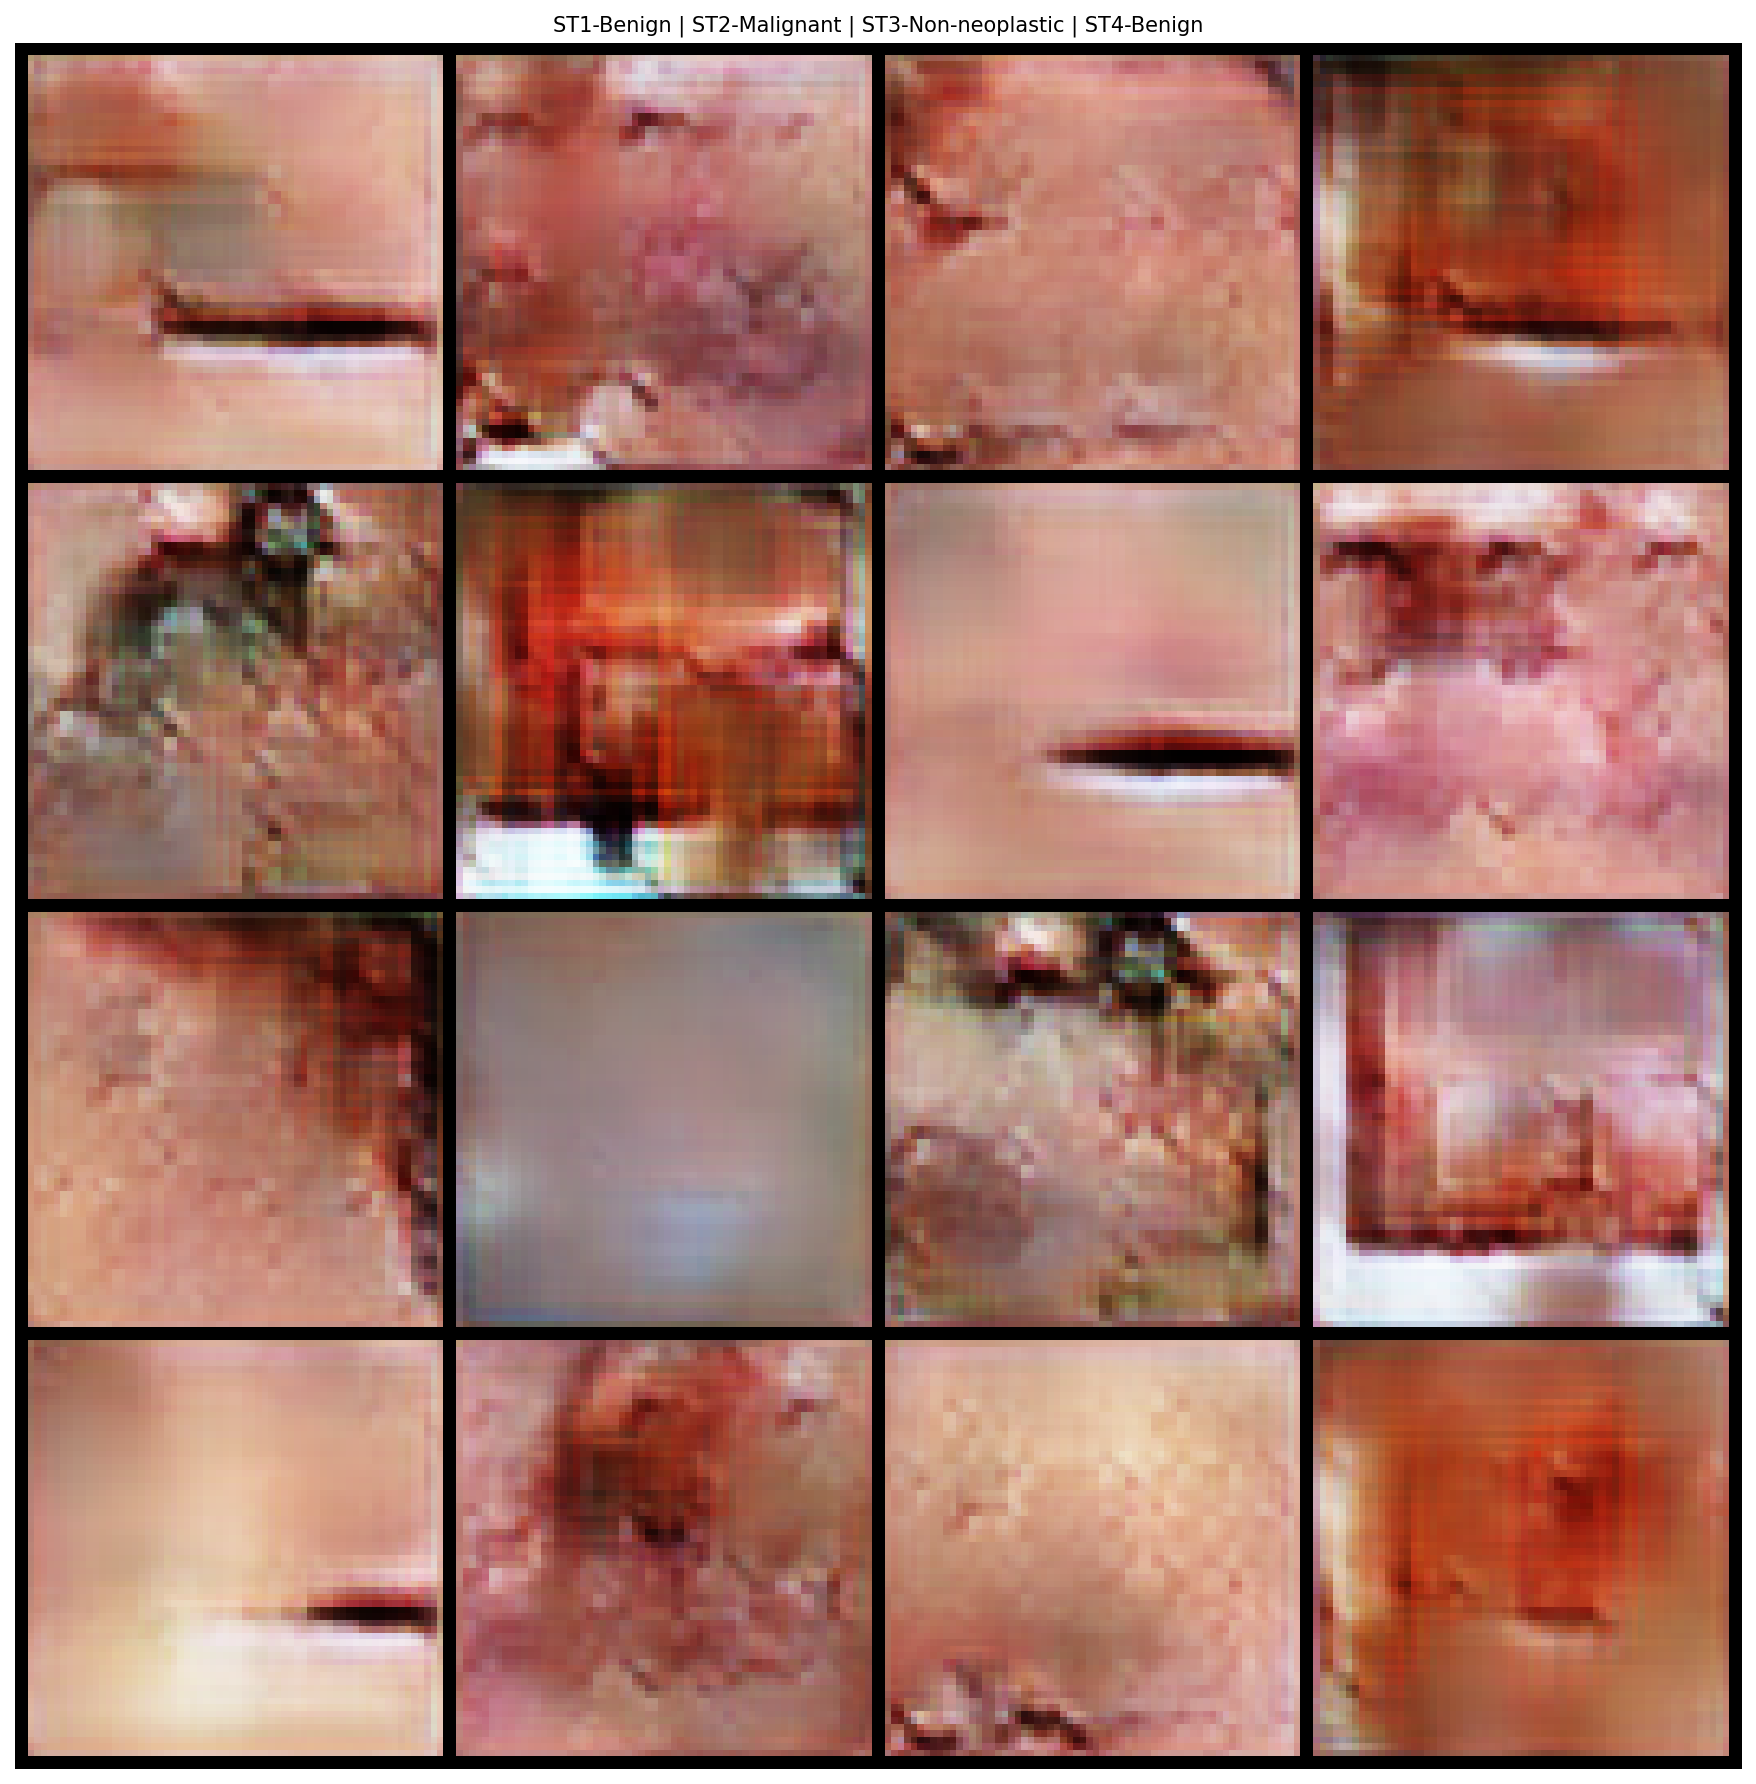

In [46]:
from IPython.display import Image as IPyImage, display

runs = sorted(OUTPUT_DIR.glob("*/samples"), key=lambda p: p.stat().st_mtime, reverse=True)
if not runs:
    print("No samples yet.")
else:
    grids = sorted(runs[0].glob("samples_epoch_*.png"))
    if not grids:
        print(f"No grids in {runs[0]} yet.")
    else:
        latest = grids[-1]
        print("Latest grid:", latest)
        display(IPyImage(filename=str(latest)))

## 10. Generate synthetic images for underrepresented skin tones

After training, point `GEN_CKPT` at the checkpoint you want to sample from and run `src/generate.py`. Defaults below produce 500 images each for FST 5 and FST 6 across all three lesion types, plus a 4×4 preview grid and a metadata CSV that follows the Fitzpatrick17k schema (so it can be merged into a combined dataloader for the downstream classifier).

In [47]:
ckpts = sorted(OUTPUT_DIR.glob("*/checkpoints/*.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
assert ckpts, f"No checkpoints under {OUTPUT_DIR}"
GEN_CKPT = ckpts[0]
# GEN_CKPT = "/content/drive/MyDrive/SkinLesionBiasReduction/outputs/wgan_20260502_210952/checkpoints/checkpoint_epoch_0140.pt"
print("Generating from:", GEN_CKPT)

GEN_OUTPUT_DIR  = PROJECT_ROOT / "generated_images"
GEN_NUM_SAMPLES = 100
GEN_TARGET_FST  = "5 6"  # Fitzpatrick scale (1-6); 5 & 6 are the underrepresented cells

Generating from: /content/drive/MyDrive/SkinLesionBiasReduction/outputs/wgan_20260503_062037/checkpoints/final_model.pt


In [48]:
!python src/generate.py \
    --checkpoint "{GEN_CKPT}" \
    --output_dir "{GEN_OUTPUT_DIR}" \
    --num_samples {GEN_NUM_SAMPLES} \
    --target_skin_tones {GEN_TARGET_FST} \
    --target_lesion_types benign malignant non-neoplastic \
    --batch_size 64 \
    --save_grid \
    --create_csv \
    --device cuda

Using device: cuda
Loading generator from /content/drive/MyDrive/SkinLesionBiasReduction/outputs/wgan_20260503_062037/checkpoints/final_model.pt...
Auto-detected gen_arch='upsample'
Auto-detected use_attention=True
Loaded checkpoint from epoch 200

Generating 100 samples for each class combination...
Target skin tones: [5, 6]
Target lesion types: ['benign', 'malignant', 'non-neoplastic']

Generating: Fitzpatrick 5, benign
ST5-benign: 100% 2/2 [00:00<00:00,  4.98it/s]

Generating: Fitzpatrick 5, malignant
ST5-malignant: 100% 2/2 [00:00<00:00,  7.95it/s]

Generating: Fitzpatrick 5, non-neoplastic
ST5-non-neoplastic: 100% 2/2 [00:00<00:00,  8.01it/s]

Generating: Fitzpatrick 6, benign
ST6-benign: 100% 2/2 [00:00<00:00,  7.76it/s]

Generating: Fitzpatrick 6, malignant
ST6-malignant: 100% 2/2 [00:00<00:00,  8.74it/s]

Generating: Fitzpatrick 6, non-neoplastic
ST6-non-neoplastic: 100% 2/2 [00:00<00:00,  8.33it/s]

Generation complete!
Total images generated: 600
Images saved to: /content/dri

## 11. M2M (skin-diff) diffusion baseline

End-to-end smoke test for the **From Majority to Minority** pipeline (Wang et al., MICCAI ISIC 2024). Vendored at `third_party/skin-diff/`.

The flow has four stages:
1. **Prepare** — filter the M2M-bundled `Fitz_subset.csv` to images we have locally and emit train/test CSVs + LoRA JSON (`src/prepare_m2m_dataset.py`).
2. **Textual Inversion** — learn one placeholder token per disease (`<dis>-class`) from FST 1–2 majority images.
3. **LoRA fine-tune** — fine-tune SD 2.1-base on (image, prompt) pairs that combine the TI tokens with skin-tone phrasing.
4. **Img2Img inference** — transfer learned lesion concepts onto FST 5–6 phrasing using a real FST 1–2 image as the structural anchor.

> **Smoke test first:** the defaults below run TI for one condition × 50 steps and LoRA for 100 steps just to confirm the pipeline executes. Bump `M2M_TI_MAX_STEPS`, `M2M_LORA_MAX_STEPS`, and `M2M_CONDITIONS` for a real run.

> **Image source:** M2M was trained on raw 512² derm images, not segmented ones. Defaults below use the raw `/content/local_images` cache from section 2.1 — do **not** point this at a `medsam3`/`sam3` dir.

### 11.1 Install M2M dependencies

Pinned to the versions in `third_party/skin-diff/requirements.txt`. We only install the ML-stack subset (`diffusers`, `transformers`, `accelerate`, `peft`, `datasets`, `safetensors`) — the rest of their pins are torch / NVIDIA wheels that Colab already provides.

In [ ]:
!pip install --quiet \
    'diffusers==0.35.2' \
    'transformers==4.54.1' \
    'accelerate==1.9.0' \
    'peft==0.17.1' \
    'datasets==4.1.1' \
    'safetensors==0.5.3'

### 11.2 M2M paths and smoke-test hyperparameters

Edit `M2M_IMAGE_DIR` if you want to use a different image cache. `M2M_CONDITIONS` is the per-disease list TI runs over — for a full reproduction use all 7; for a smoke test, leave it at the single `basal cell carcinoma` so TI only takes ~1 minute on H100.

In [ ]:
# --- M2M paths ---
M2M_REPO_DIR     = PROJECT_ROOT / "third_party/skin-diff"
M2M_IMAGE_DIR    = LOCAL_IMAGE_DIR                                  # raw /content/local_images from section 2.1
M2M_BUNDLED_CSV  = M2M_REPO_DIR / "data_splits/Fitz_subset.csv"     # ships with the repo (2,707 rows)
M2M_OUTPUT_DIR   = PROJECT_ROOT / "outputs/m2m"                     # everything M2M writes lands here
M2M_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- M2M model + split config ---
M2M_MODEL_NAME = "stabilityai/stable-diffusion-2-1-base"
M2M_SPLIT_NAME = "light_and_dark_flex_to_dark"
M2M_SEED       = 0
M2M_RESOLUTION = 512

# --- Smoke-test hyperparameters (bump for a real run) ---
M2M_CONDITIONS = ["basal_cell_carcinoma"]  # full set: see prepare_m2m_dataset.M2M_CONDITIONS
M2M_TI_MAX_STEPS    = 50      # paper: 500
M2M_TI_BATCH_SIZE   = 2       # paper: 4 (2 fits more comfortably for the smoke test)
M2M_TI_GRAD_ACCUM   = 1       # paper: 4
M2M_LORA_MAX_STEPS  = 100     # paper: 3000
M2M_LORA_BATCH_SIZE = 4
M2M_LORA_RANK       = 8

# --- Inference smoke test ---
M2M_INFER_NUM_IMAGES_PER_PROMPT = 2
M2M_INFER_STRENGTH              = 0.5
M2M_INFER_GUIDANCE              = 2.0
M2M_INFER_NUM_INFERENCE_STEPS   = 50

print("M2M_REPO_DIR:    ", M2M_REPO_DIR,    "exists:", M2M_REPO_DIR.exists())
print("M2M_IMAGE_DIR:   ", M2M_IMAGE_DIR,   "exists:", Path(M2M_IMAGE_DIR).exists())
print("M2M_BUNDLED_CSV: ", M2M_BUNDLED_CSV, "exists:", M2M_BUNDLED_CSV.exists())
print("M2M_OUTPUT_DIR:  ", M2M_OUTPUT_DIR)
assert M2M_REPO_DIR.exists(),    f"{M2M_REPO_DIR} missing — did you re-pull the repo (section 2.2)?"
assert M2M_BUNDLED_CSV.exists(), f"{M2M_BUNDLED_CSV} missing — vendored repo is incomplete"

### 11.3 Prepare M2M splits

Reads the bundled `Fitz_subset.csv`, drops md5hashes whose `<md5>.jpg` is missing from the local image cache, then emits:
- `train_<split>_seed=<S>.csv` — FST 1–2 majority + 8 sampled FST 5–6 rows per disease
- `test_<split>_seed=<S>.csv`  — held-out FST 5–6 rows
- `train_lora_<split>_seed=<S>.json` — image_path / prompt pairs for the LoRA stage

In [ ]:
!python src/prepare_m2m_dataset.py \
    --m2m_csv "{M2M_BUNDLED_CSV}" \
    --image_dir "{M2M_IMAGE_DIR}" \
    --output_dir "{M2M_REPO_DIR}/data_splits" \
    --split_name "{M2M_SPLIT_NAME}" \
    --seed {M2M_SEED}

M2M_TRAIN_CSV  = M2M_REPO_DIR / f"data_splits/train_{M2M_SPLIT_NAME}_seed={M2M_SEED}.csv"
M2M_TEST_CSV   = M2M_REPO_DIR / f"data_splits/test_{M2M_SPLIT_NAME}_seed={M2M_SEED}.csv"
M2M_LORA_JSON  = M2M_REPO_DIR / f"data_splits/train_lora_{M2M_SPLIT_NAME}_seed={M2M_SEED}.json"
print("Train CSV:", M2M_TRAIN_CSV, "exists:", M2M_TRAIN_CSV.exists())
print("Test CSV: ", M2M_TEST_CSV,  "exists:", M2M_TEST_CSV.exists())
print("LoRA JSON:", M2M_LORA_JSON, "exists:", M2M_LORA_JSON.exists())

### 11.4 Textual Inversion (per condition)

For each disease in `M2M_CONDITIONS`, learn a `<dis>-class` placeholder token initialised from `"skin"`. Per-condition output lands at `outputs/m2m/textual_inversion/<split>_seed=<S>/<condition>/`.

H100 budget per condition (paper settings, 500 steps): ~5–8 minutes. Smoke-test (50 steps): ~1 minute.

In [ ]:
M2M_TI_OUTPUT_DIR = M2M_OUTPUT_DIR / f"textual_inversion/{M2M_SPLIT_NAME}_seed={M2M_SEED}"
M2M_TI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for cond in M2M_CONDITIONS:
    out = M2M_TI_OUTPUT_DIR / cond
    token = f"{cond[:3]}-class"
    print(f"\n========== TI: {cond}  (token={token!r}) ==========")
    !accelerate launch third_party/skin-diff/scripts/textual_inversion.py \
        --pretrained_model_name_or_path="{M2M_MODEL_NAME}" \
        --train_data_dir="{M2M_IMAGE_DIR}" \
        --fitz_split_csv="{M2M_TRAIN_CSV}" \
        --learnable_property="object" \
        --placeholder_token="{token}" \
        --initializer_token="skin" \
        --resolution={M2M_RESOLUTION} \
        --train_batch_size={M2M_TI_BATCH_SIZE} \
        --gradient_accumulation_steps={M2M_TI_GRAD_ACCUM} \
        --mixed_precision="fp16" \
        --max_train_steps={M2M_TI_MAX_STEPS} \
        --learning_rate=5.0e-04 \
        --scale_lr \
        --lr_scheduler="constant" \
        --lr_warmup_steps=0 \
        --output_dir="{out}" \
        --class_name="{cond}" \
        --repeats=10

### 11.5 Aggregate learned embeddings

Merges all per-condition `learned_embeds.safetensors` into a single `aggregated_embeds_SEED=<S>.pt` so LoRA training and inference can load every disease token in one shot.

In [ ]:
import glob
import torch
from safetensors import safe_open

merged = {}
for fp in glob.glob(str(M2M_TI_OUTPUT_DIR / "*/learned_embeds.safetensors")):
    with safe_open(fp, framework="pt", device="cpu") as f:
        for k in f.keys():
            merged[k] = f.get_tensor(k)
    print(f"  + {fp}")

M2M_TI_EMBED_PATH = M2M_TI_OUTPUT_DIR / f"aggregated_embeds_SEED={M2M_SEED}.pt"
torch.save(merged, M2M_TI_EMBED_PATH)
print(f"\n[write] {M2M_TI_EMBED_PATH}")
print("Tokens:", list(merged.keys()))

### 11.6 LoRA fine-tune

Fine-tunes SD 2.1-base with LoRA (rank 8) on the (image, prompt) pairs from the LoRA JSON. Prompts use the TI tokens from 11.4–11.5 plus skin-tone phrasing — e.g. `"An image of bas-class on the skin of a very light-skinned individual"`.

> **Trailing slash matters:** `train_text_to_image_lora.py:650` does bare string concat `train_data_dir + image_path`, so `--train_data_dir` must end with `/`.

H100 budget (paper, 3000 steps, batch 4): ~1.5–2 hours. Smoke-test (100 steps): ~3 minutes.

In [ ]:
M2M_LORA_OUTPUT_DIR = M2M_OUTPUT_DIR / f"lora_weights/{M2M_SPLIT_NAME}_seed={M2M_SEED}"
M2M_LORA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Trailing slash required — see note in 11.6 markdown.
M2M_IMAGE_DIR_SLASH = str(M2M_IMAGE_DIR).rstrip("/") + "/"

!accelerate launch --mixed_precision="fp16" third_party/skin-diff/scripts/train_text_to_image_lora.py \
    --pretrained_model_name_or_path="{M2M_MODEL_NAME}" \
    --train_data_dir="{M2M_IMAGE_DIR_SLASH}" \
    --dataloader_num_workers=4 \
    --image_column="image" \
    --caption_column="prompt" \
    --resolution={M2M_RESOLUTION} \
    --train_batch_size={M2M_LORA_BATCH_SIZE} \
    --gradient_accumulation_steps=1 \
    --max_train_steps={M2M_LORA_MAX_STEPS} \
    --learning_rate=5e-06 \
    --max_grad_norm=1 \
    --lr_scheduler="constant" \
    --lr_warmup_steps=0 \
    --output_dir="{M2M_LORA_OUTPUT_DIR}" \
    --checkpointing_steps=1000 \
    --rank={M2M_LORA_RANK} \
    --embed_path="{M2M_TI_EMBED_PATH}" \
    --json_path="{M2M_LORA_JSON}"

### 11.7 Img2Img inference smoke test

Loads SD 2.1-base + the merged TI embeddings + the LoRA weights, then runs `StableDiffusionImg2ImgPipeline` over the first few FST 1–2 majority images while *prompting* for FST 5–6 — the M2M trick that transfers a learned lesion concept onto a different skin tone.

Outputs go to `outputs/m2m/inference_smoke/<split>_seed=<S>/` along with a metadata CSV mirroring the Fitzpatrick17k schema.

In [ ]:
import json
import random

import PIL
import pandas as pd
import torch
from PIL import Image
from diffusers import StableDiffusionImg2ImgPipeline
from transformers import CLIPTokenizer, CLIPTextModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    M2M_MODEL_NAME, torch_dtype=torch.float16
).to(device)


def load_ti_embeddings(pipe, embed_path, model_name):
    tokenizer = CLIPTokenizer.from_pretrained(model_name, subfolder="tokenizer")
    text_encoder = CLIPTextModel.from_pretrained(model_name, subfolder="text_encoder")
    for token, embedding in torch.load(embed_path, map_location="cpu").items():
        tokenizer.add_tokens(token)
        text_encoder.resize_token_embeddings(len(tokenizer))
        token_id = tokenizer.convert_tokens_to_ids(token)
        text_encoder.get_input_embeddings().weight.data[token_id] = embedding.to(
            text_encoder.get_input_embeddings().weight.dtype
        )
    return tokenizer, text_encoder


tokenizer, text_encoder = load_ti_embeddings(pipe, M2M_TI_EMBED_PATH, M2M_MODEL_NAME)
pipe.tokenizer = tokenizer
pipe.text_encoder = text_encoder.to(device)

pipe.load_lora_weights(str(M2M_LORA_OUTPUT_DIR))
pipe.to(dtype=torch.float16)

TONE_PROMPT = {
    1: "a very light-skinned",
    2: "a light-skinned",
    5: "a dark-skinned",
    6: "a very dark-skinned",
}
TOKEN_FOR = {
    "basal cell carcinoma":     "bas-class",
    "folliculitis":             "fol-class",
    "nematode infection":       "nem-class",
    "neutrophilic dermatoses":  "neu-class",
    "prurigo nodularis":        "pru-class",
    "psoriasis":                "pso-class",
    "squamous cell carcinoma":  "squ-class",
}

with open(M2M_LORA_JSON) as f:
    lora_rows = json.load(f)

infer_dir = M2M_OUTPUT_DIR / f"inference_smoke/{M2M_SPLIT_NAME}_seed={M2M_SEED}"
infer_dir.mkdir(parents=True, exist_ok=True)

records = []
for row in lora_rows[:4]:                          # smoke test: 4 source images
    label = row["label"]
    if label not in TOKEN_FOR:
        continue
    src_path = Path(M2M_IMAGE_DIR) / row["image_path"]
    if not src_path.exists():
        continue
    src_img = Image.open(src_path).convert("RGB").resize(
        (M2M_RESOLUTION, M2M_RESOLUTION), resample=PIL.Image.BILINEAR
    )

    target_fst = random.choice([5, 6])
    prompt = (
        f"An image of {TOKEN_FOR[label]} on the skin of "
        f"{TONE_PROMPT[target_fst]} individual"
    )
    print(f"  -> {src_path.name}: target_fst={target_fst}  prompt={prompt!r}")
    out_imgs = pipe(
        prompt=prompt,
        image=src_img,
        strength=M2M_INFER_STRENGTH,
        guidance_scale=M2M_INFER_GUIDANCE,
        num_inference_steps=M2M_INFER_NUM_INFERENCE_STEPS,
        num_images_per_prompt=M2M_INFER_NUM_IMAGES_PER_PROMPT,
    ).images

    src_id = src_path.stem
    for idx, img in enumerate(out_imgs):
        name = f"{src_id}_to_fst{target_fst}_{idx}.jpg"
        img.resize((256, 256)).save(infer_dir / name)
        records.append({
            "md5hash": f"{src_id}_to_fst{target_fst}_{idx}",
            "label": label,
            "fitzpatrick_scale": target_fst,
            "three_partition_label": "synthetic",
            "is_synthetic": True,
            "source_md5hash": src_id,
        })

df_synth = pd.DataFrame(records)
df_synth.to_csv(infer_dir / "generated_metadata.csv", index=False)
print(f"\n[write] {infer_dir}/generated_metadata.csv  ({len(df_synth)} rows)")
df_synth